## Phase 1: Exploratory Data Analysis

In [1]:
import pandas as pd        
import numpy as np
import matplotlib.pyplot as plt   
import seaborn as sns      

df = pd.read_csv("../data/train.csv")

df.head()   #shows first 5 rows of data
print(df.shape)  #shows a tuple of (rows, columns) in this dataset (891, 12) means 891 passengers with 12 columns of info
df.info()   #for each column it shows its name, data type, non null count (how many values are not null)

(891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [2]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

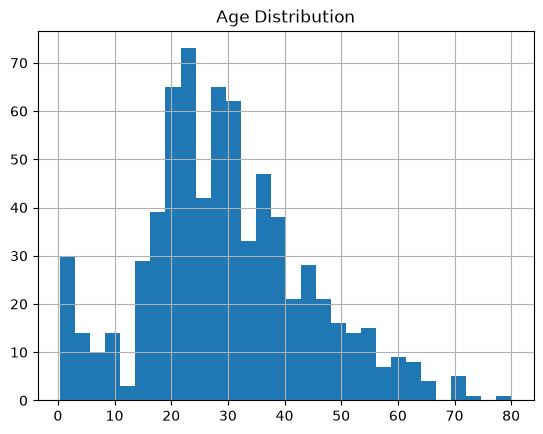

In [3]:
df['Age'].hist(bins=30)
plt.title('Age Distribution')
plt.show()

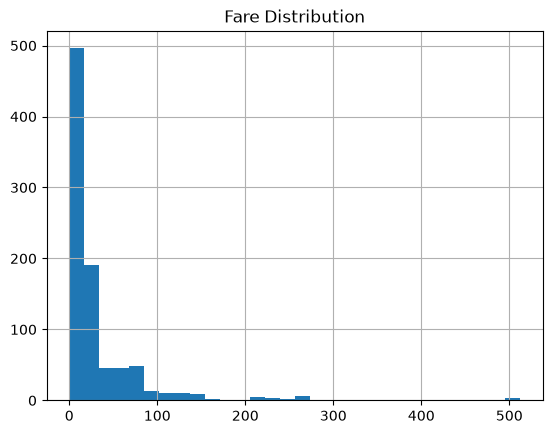

In [4]:
df['Fare'].hist(bins=30)
plt.title('Fare Distribution')
plt.show()

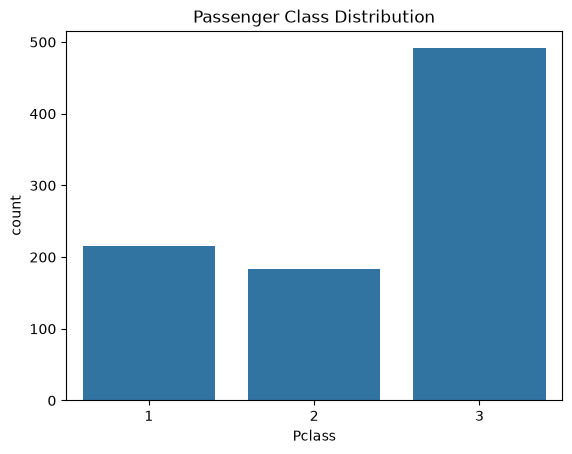

In [5]:
sns.countplot(x='Pclass', data=df)
plt.title('Passenger Class Distribution')
plt.show()

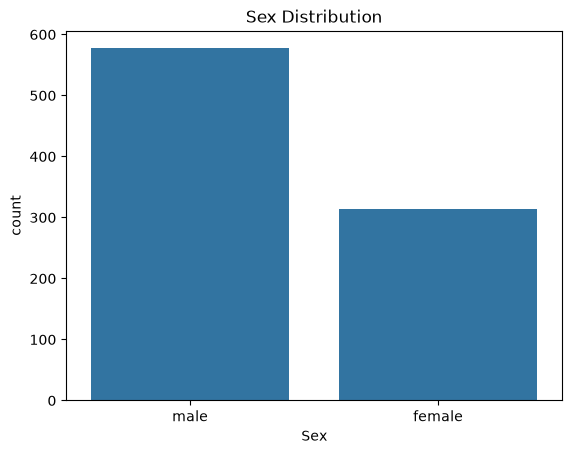

In [6]:
sns.countplot(x='Sex', data=df)
plt.title('Sex Distribution')
plt.show()

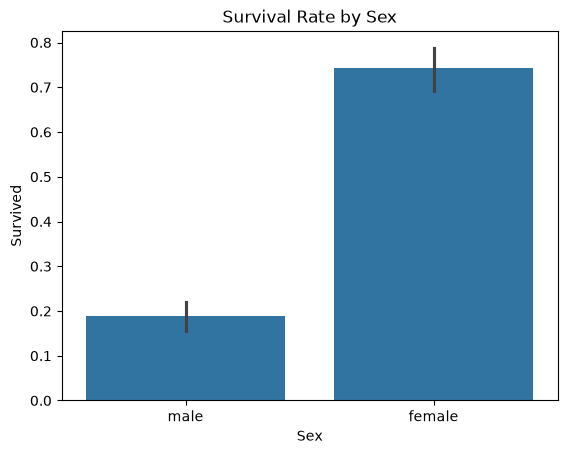

In [7]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Sex')
plt.show()

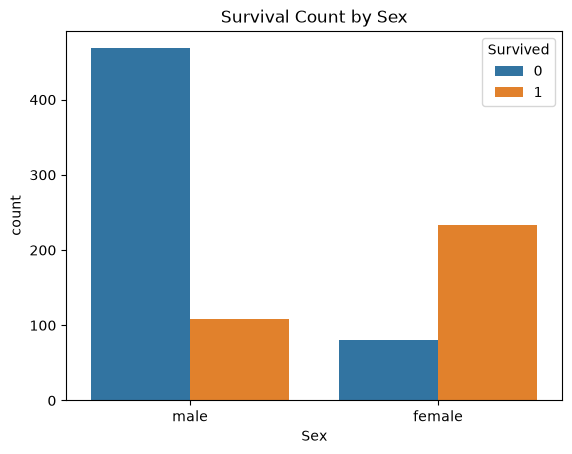

In [8]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival Count by Sex')
plt.show()

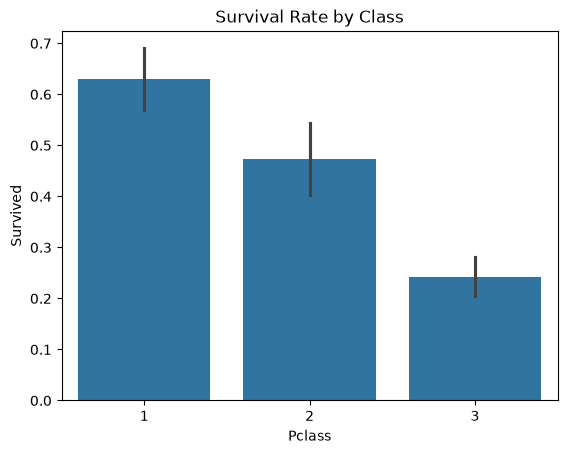

In [9]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Class')
plt.show()

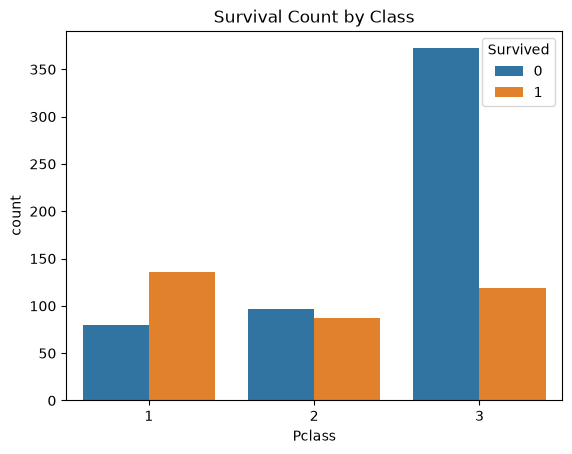

In [10]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival Count by Class')
plt.show()

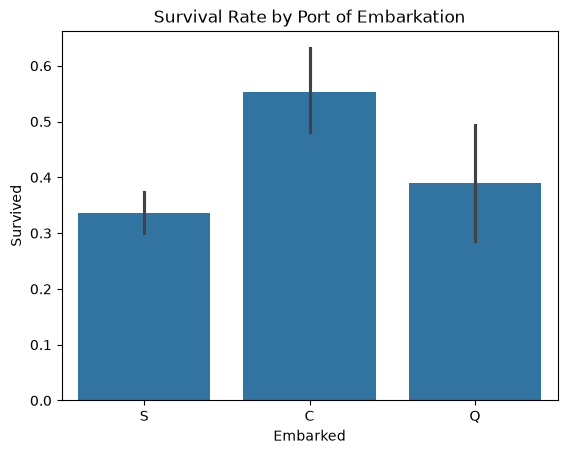

In [11]:
sns.barplot(x='Embarked', y='Survived', data=df)
plt.title('Survival Rate by Port of Embarkation')
plt.show()

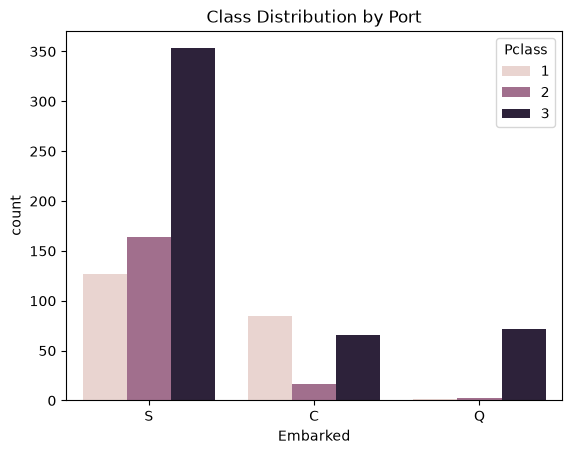

In [12]:
sns.countplot(x='Embarked', hue='Pclass', data=df)
plt.title('Class Distribution by Port')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

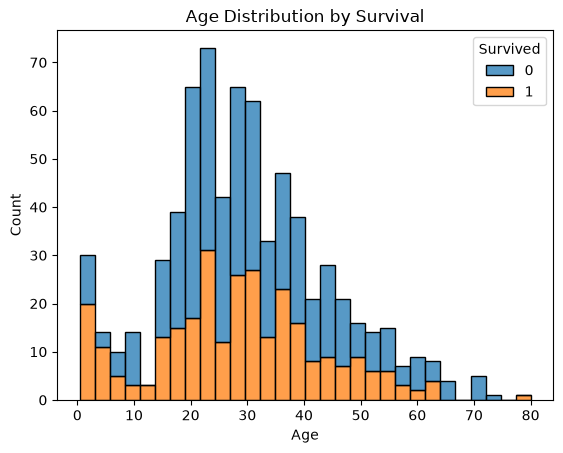

In [13]:
sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', bins=30)
plt.title('Age Distribution by Survival')
plt.show

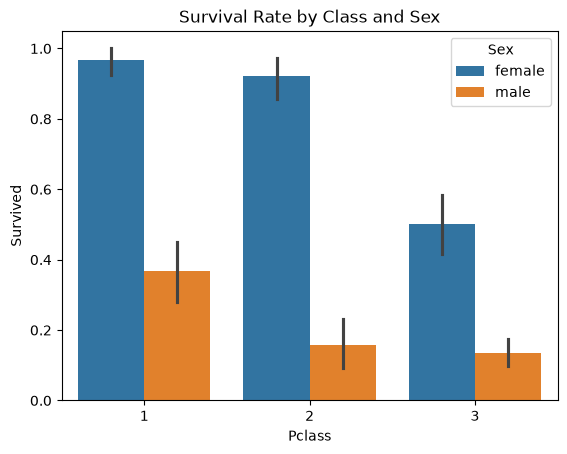

In [14]:
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df)
plt.title('Survival Rate by Class and Sex')
plt.show()

In [15]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


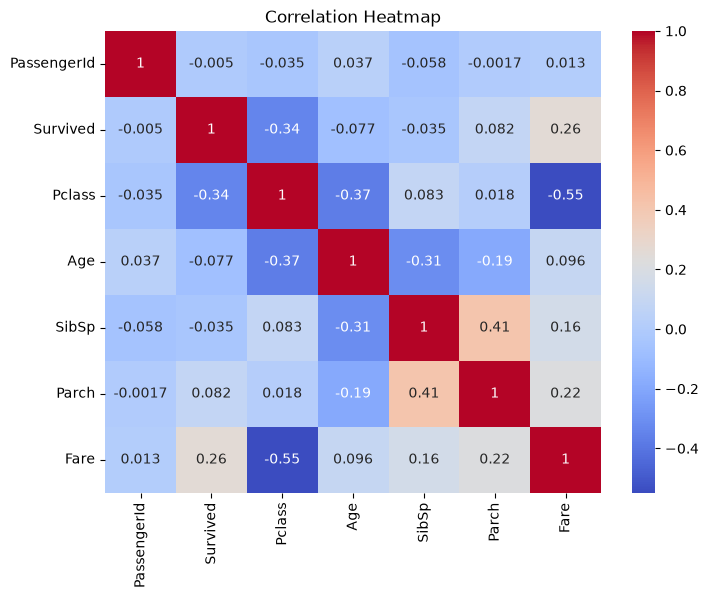

In [16]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Titanic Survival Prediction - Exploratory Data Analysis

This notebook explores the Titanic Dataset (Kaggle competition) its aim is to understand patterns in passenger survival before building predictive models.

**DATASET**  The Training dataset consists of information (sex, age, class etc..) for 891 passengers.

**GOAL** Identify which features (sex, age, class etc..) are most associated with passenger survival and understand data quality (missing values, outliers) that will need to be addressed in preprocessing.

**KEY FINDINGS** 
- Baseline accuracy (always predict passenger didnt survive) is 549/891 = 61.6% - any real model need to confidently beat this.
- Sex is the strongest indicator of survival : Women ~ 74%, Men ~ 19%
- Pclass matters a lot: 1st class ~ 63%, 3rd class ~ 24%
- The combination of sex and pclass is vital : 1st class Women ~ 97%, 3rd class Men ~ 13%
- Embarked acts as a proxy for class : Cherbourg has a higher proportion of 1st class passengets than other ports
- Age shows a "children first" policy was followed leading to high survival rates.
- Missing Data: Age (177), Cabin (687), Embarked (2)
- Cabin is too sparse to be used directly 

## Phase 2: Data Cleaning

In [17]:
df['Age'].mean()  #Adds all values, divides by count

np.float64(29.69911764705882)

In [18]:
df['Age'].median()  #Sorts every valuefrom smallest to largest, takes the exact middle one, only cares about position 

np.float64(28.0)

In [19]:
df['Age_filled'] = df['Age'].fillna(df['Age'].median())

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
 12  Age_filled   891 non-null    float64
dtypes: float64(3), int64(5), str(5)
memory usage: 90.6 KB


In [21]:
df['Embarked'].mode()  #Returns a small series containg the most frequently occured value in Embarked

0    S
Name: Embarked, dtype: str

In [22]:
df['Embarked_filled'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) #Created a new column Embarked_filled, searched on the Embarked column and if there is a null values it assigns the most common which is 'S'

In [23]:
df['HasCabin'] = df['Cabin'].notnull()  #creates a column 'HasCabin' with True or False based on if the column 'Cabin' has a value

In [24]:
df['HasCabin'] = df['HasCabin'].astype(int) #converts True to 1, False to 0

In [25]:
df.isnull().sum()

PassengerId          0
Survived             0
Pclass               0
Name                 0
Sex                  0
Age                177
SibSp                0
Parch                0
Ticket               0
Fare                 0
Cabin              687
Embarked             2
Age_filled           0
Embarked_filled      0
HasCabin             0
dtype: int64

# Titanic Survival Prediction -  Data Cleaning

**Changes Made**

- In the original dataset the columns Age, Cabin and Embarked had null values, which needed to be filled
- For Age a new column Age_filled was created, where every null value was replaced with the median one, later a better way to fill the null Ages will be used (Probably by using Sex, Class and Title)
- For Embarked a new column Embarked_filled was created , where every null value was replaced with the most common one
- For Cabin a new column HasCabin was created, where if there was a value in Cabin it was replaced with 1 (indicating the passenger had a value) if it was null it was replaced with 0 (indicating no cabin)

## Phase 3: Feature Engineering

In [26]:
df['Name'].head(10)

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7                       Palsson, Master. Gosta Leonard
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                  Nasser, Mrs. Nicholas (Adele Achem)
Name: Name, dtype: str

In [27]:
name = "Braund, Mr. Owen Harris"
part1 = name.split(',')
print(part1)
part2 = part1[1]
print(part2)
part3 = part2.split('.')
title = part3[0].strip()
print(title)

['Braund', ' Mr. Owen Harris']
 Mr. Owen Harris
Mr


In [28]:
def extract_title(name):
    title = name.split(',')[1].split('.')[0].strip()
    return title

In [29]:
df['Title'] = df['Name'].apply(extract_title)

In [30]:
df['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [31]:
Title_mapping = {
    'Mlle': 'Miss',
    'Mme' : 'Mrs',
    'Ms' : 'Miss',
    'Dr' : 'Rare',
    'Rev' : 'Rare',
    'Major' : 'Rare',
    'Col' : 'Rare',
    'Don' : 'Rare',
    'Lady' : 'Rare',
    'Sir' : 'Rare',
    'Capt' : 'Rare',
    'the Countess' : 'Rare',
    'Jonkheer' : 'Rare'
}

In [32]:
df['Title_Organised'] = df['Title'].replace(Title_mapping)

In [33]:
df['Title_Organised'].value_counts()

Title_Organised
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

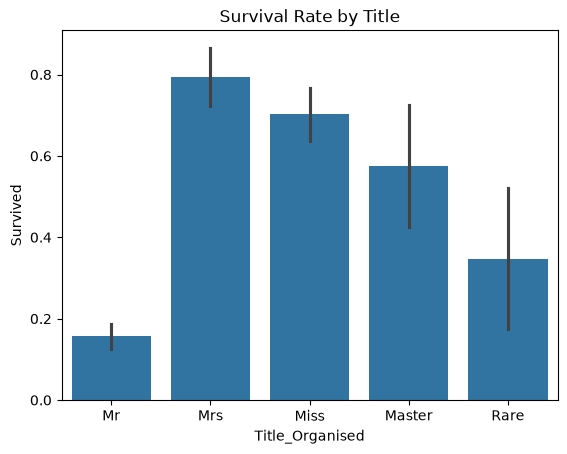

In [34]:
sns.barplot(x='Title_Organised', y='Survived', data=df)
plt.title('Survival Rate by Title')
plt.show()

In [35]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [36]:
df[['Name', 'SibSp', 'Parch', 'FamilySize']].head(10)

,Name,SibSp,Parch,FamilySize
0,"Braund, Mr. Owen Harris",1,0,2
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0,2
2,"Heikkinen, Miss. Laina",0,0,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0,2
4,"Allen, Mr. William Henry",0,0,1
5,"Moran, Mr. James",0,0,1
6,"McCarthy, Mr. Timothy J",0,0,1
7,"Palsson, Master. Gosta Leonard",3,1,5
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",0,2,3
9,"Nasser, Mrs. Nicholas (Adele Achem)",1,0,2


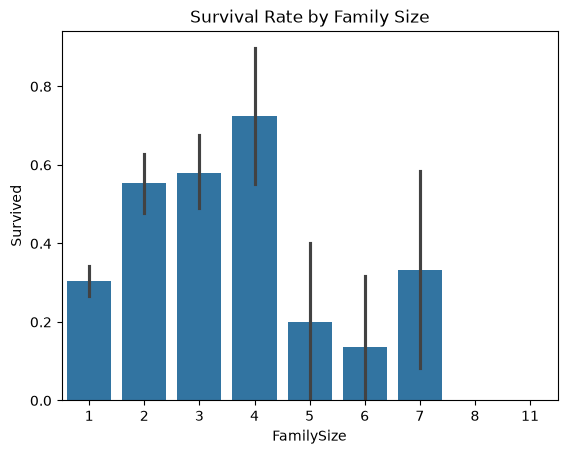

In [37]:
sns.barplot(x='FamilySize', y='Survived', data=df)
plt.title('Survival Rate by Family Size')
plt.show()

In [38]:
df['FamilySize'].value_counts().sort_index()

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

In [39]:
df['isAlone'] = df['FamilySize'].eq(1)

In [40]:
df['isAlone'] = df['isAlone'].astype(int)

In [41]:
df['isAlone']

0      0
1      0
2      1
3      0
4      1
      ..
886    1
887    1
888    0
889    1
890    1
Name: isAlone, Length: 891, dtype: int64

In [42]:
df[['SibSp', 'Parch', 'FamilySize', 'isAlone']].head(5)

,SibSp,Parch,FamilySize,isAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


In [43]:
df['Age_Group'] = pd.cut(df['Age_filled'], bins=[0, 12, 19, 59, 100], labels = ['Child', 'Teen', 'Adult', 'Senior'])

In [44]:
df['Age_Group'].value_counts()

Age_Group
Adult     701
Teen       95
Child      69
Senior     26
Name: count, dtype: int64

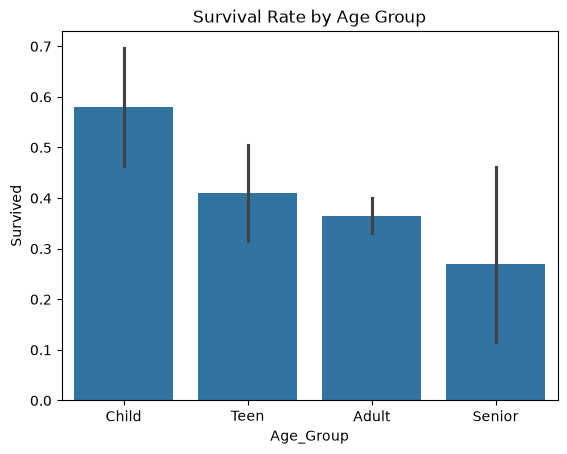

In [45]:
sns.barplot(x='Age_Group', y='Survived', data=df)
plt.title('Survival Rate by Age Group')
plt.show()

# Titanic Survival Prediction - Feature Engineering

**Changes Made**

- A new column `Title` was created by using a function to extract the title from each passenger's `Name`
- The `Title` column contained 17 unique values, some of which were used only once or twice, meaning they don't offer reliable predictive value due to their low frequency
- These rare values were either grouped into existing categories that describe the same title, or grouped into a new "Rare" category (Mlle→Miss, Mme→Mrs, Ms→Miss, rare rank/profession titles→Rare), producing a cleaner column called `Title_Organised`
- It's important to note that the Rare group, being very small and heterogeneous (mixing nobility, clergy, and military titles), may dilute predictive value — this is reflected in its much wider error bar in the survival rate plot compared to other groups
- A new column `FamilySize` was created using `SibSp` + `Parch` + 1 (the +1 accounts for the passenger themselves, not just their relatives) — this represents the total size of each passenger's family group traveling together
- A new column `isAlone` was created for every passenger, set to 1 if their `FamilySize` equals 1 (traveling alone), and 0 otherwise
- Survival rate by `FamilySize` showed a non-obvious pattern: solo travelers had lower survival (~30%), small families of 2-4 had the highest survival (up to ~72%), and large families of 5+ had sharply lower survival (as low as ~13-20%) — likely reflecting both prioritized evacuation for small family units and lifeboat capacity/coordination struggles for large families
- A new column `Age_Group` was created by binning `Age_filled` into four categories: Child (0-12), Teen (13-19), Adult (20-59), Senior (60+)

## Phase 4: Preprocessing Pipeline

In [46]:
df['Sex_encoded'] = df['Sex'].replace({'male': 0, 'female': 1})

In [47]:
df['Sex_encoded'].value_counts()

Sex_encoded
0    577
1    314
Name: count, dtype: int64

In [48]:
pd.get_dummies(df['Embarked_filled'])

,C,Q,S
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True
...,...,...,...
886,False,False,True
887,False,False,True
888,False,False,True
889,True,False,False


In [49]:
df = pd.concat([df, pd.get_dummies(df['Embarked_filled'])], axis=1)

In [50]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Age_filled',
       'Embarked_filled', 'HasCabin', 'Title', 'Title_Organised', 'FamilySize',
       'isAlone', 'Age_Group', 'Sex_encoded', 'C', 'Q', 'S'],
      dtype='str')

In [51]:
df[['Embarked_filled', 'C', 'Q', 'S']].head()

,Embarked_filled,C,Q,S
0,S,False,False,True
1,C,True,False,False
2,S,False,False,True
3,S,False,False,True
4,S,False,False,True


In [52]:
pd.get_dummies(df['Embarked_filled'], drop_first=True)

,Q,S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True
...,...,...
886,False,True
887,False,True
888,False,True
889,False,False


In [53]:
df = df.drop(columns=['S'])

In [54]:
df['C'] = df['C'].astype(int)
df['Q'] = df['Q'].astype(int)

In [55]:
list(df.columns)

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked',
 'Age_filled',
 'Embarked_filled',
 'HasCabin',
 'Title',
 'Title_Organised',
 'FamilySize',
 'isAlone',
 'Age_Group',
 'Sex_encoded',
 'C',
 'Q']

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   PassengerId      891 non-null    int64   
 1   Survived         891 non-null    int64   
 2   Pclass           891 non-null    int64   
 3   Name             891 non-null    str     
 4   Sex              891 non-null    str     
 5   Age              714 non-null    float64 
 6   SibSp            891 non-null    int64   
 7   Parch            891 non-null    int64   
 8   Ticket           891 non-null    str     
 9   Fare             891 non-null    float64 
 10  Cabin            204 non-null    str     
 11  Embarked         889 non-null    str     
 12  Age_filled       891 non-null    float64 
 13  Embarked_filled  891 non-null    str     
 14  HasCabin         891 non-null    int64   
 15  Title            891 non-null    str     
 16  Title_Organised  891 non-null    str     
 17  FamilySi

In [57]:
df['Age_Group_encoded'] = df['Age_Group'].astype(str).replace({'Child': 0, 'Teen': 1, 'Adult': 2, 'Senior': 3})

In [58]:
df['Age_Group_encoded'].value_counts()

Age_Group_encoded
2    701
1     95
0     69
3     26
Name: count, dtype: int64

In [59]:
df['Age_Group'].value_counts()

Age_Group
Adult     701
Teen       95
Child      69
Senior     26
Name: count, dtype: int64

In [60]:
df = pd.concat([df, pd.get_dummies(df['Title_Organised'])], axis=1)

In [61]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Age_filled',
       'Embarked_filled', 'HasCabin', 'Title', 'Title_Organised', 'FamilySize',
       'isAlone', 'Age_Group', 'Sex_encoded', 'C', 'Q', 'Age_Group_encoded',
       'Master', 'Miss', 'Mr', 'Mrs', 'Rare'],
      dtype='str')

In [62]:
df = df.drop(columns=['Mr'])

In [63]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Age_filled',
       'Embarked_filled', 'HasCabin', 'Title', 'Title_Organised', 'FamilySize',
       'isAlone', 'Age_Group', 'Sex_encoded', 'C', 'Q', 'Age_Group_encoded',
       'Master', 'Miss', 'Mrs', 'Rare'],
      dtype='str')

In [64]:
df['Age_Group'].value_counts()

Age_Group
Adult     701
Teen       95
Child      69
Senior     26
Name: count, dtype: int64

In [65]:
pd.set_option('display.max_rows', None)
df.dtypes

PassengerId             int64
Survived                int64
Pclass                  int64
Name                      str
Sex                       str
Age                   float64
SibSp                   int64
Parch                   int64
Ticket                    str
Fare                  float64
Cabin                     str
Embarked                  str
Age_filled            float64
Embarked_filled           str
HasCabin                int64
Title                     str
Title_Organised           str
FamilySize              int64
isAlone                 int64
Age_Group            category
Sex_encoded            object
C                       int64
Q                       int64
Age_Group_encoded      object
Master                   bool
Miss                     bool
Mrs                      bool
Rare                     bool
dtype: object

In [66]:
df['Age_Group_encoded'] = df['Age_Group_encoded'].astype(int)

In [67]:
df['Sex_encoded'] = df['Sex_encoded'].astype(int)

In [68]:
df['Master'] = df['Master'].astype(int)
df['Miss'] = df['Miss'].astype(int)
df['Mrs'] = df['Mrs'].astype(int)
df['Rare'] = df['Rare'].astype(int)

In [69]:
print(df.dtypes.to_string())

PassengerId             int64
Survived                int64
Pclass                  int64
Name                      str
Sex                       str
Age                   float64
SibSp                   int64
Parch                   int64
Ticket                    str
Fare                  float64
Cabin                     str
Embarked                  str
Age_filled            float64
Embarked_filled           str
HasCabin                int64
Title                     str
Title_Organised           str
FamilySize              int64
isAlone                 int64
Age_Group            category
Sex_encoded             int64
C                       int64
Q                       int64
Age_Group_encoded       int64
Master                  int64
Miss                    int64
Mrs                     int64
Rare                    int64


In [70]:
X = df[['Pclass', 'FamilySize', 'isAlone', 'Sex_encoded', 'Age_filled', 'Age_Group_encoded', 'C', 'Q', 'Master', 'Miss', 'Mrs', 'Rare', 'Fare', 'HasCabin']]
y = df['Survived']

In [71]:
print(X.shape)
print(y.shape)

(891, 14)
(891,)


In [72]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [73]:
print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(712, 14)
(179, 14)
(712,)
(179,)


# Titanic Survival Prediction - Preprocessing Pipeline

**Changes Made**

- A new column `Sex_encoded` was created, where male values were mapped to 0, female to 1
- The `Embarked_filled` column was one-hot encoded into two new columns, `C` and `Q` — a simple 0/1/2 mapping (S, C, Q) could not be used because it would create a false sense of order/distance that would mislead the model
- The column `S` was dropped after one-hot encoding, since when working with dummy columns, the model can determine the answer from only 2 of the 3 columns (for n categories, only n-1 columns are needed to avoid redundancy — the "dummy variable trap")
- A new column `Age_Group_encoded` was created using simple ordinal mapping (0, 1, 2, 3), since `Age_Group` has a real order (Child → Teen → Adult → Senior), unlike Embarked or Title
- `Title_Organised` was one-hot encoded into four new columns: `Master`, `Miss`, `Mrs`, `Rare`
- The column `Mr` was dropped as the baseline category, same reasoning as Embarked
- The final feature set `X` was built containing 14 features: `Pclass`, `FamilySize`, `isAlone`, `Sex_encoded`, `Age_filled`, `Age_Group_encoded`, `C`, `Q`, `Master`, `Miss`, `Mrs`, `Rare`, `Fare`, `HasCabin`. `PassengerId` was deliberately excluded, since it's just an arbitrary row identifier with no real relationship to survival. `Survived` is the target (`y`), not a feature
- `train.csv` was split into training (80%) and validation (20%) sets using `train_test_split`; `random_state=42` ensures the split is reproducible — running the same command again always produces the exact same split, which is important for fairly comparing multiple models against the same validation data
- All preprocessing logic from Phases 2-4 (cleaning, feature engineering, encoding) was migrated into `src/preprocessing.py` as reusable functions, tested end-to-end via a single `full_pipeline()` function that returns `X_train`, `X_val`, `y_train`, `y_val` ready for modeling
